In [1]:
import numpy as np

In [2]:
a=[1,2,3]

In [3]:
b=[i+1 for i in a]
b

[2, 3, 4]

In [4]:
b=map(lambda x:x+1,a)
b=list(b)

In [5]:
c=map(lambda x,y:x+y+1,a,b)
print(list(c))

[4, 6, 8]


In [6]:
d=filter(lambda x:x>20 and x<40,range(1,90))
d=list(d)
d

[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]

In [7]:
import math as m

In [8]:

print(m.sin(1))
print(m.tan(1))
print(m.log(1))
print(m.exp(1))
print(m.atan(1))

0.8414709848078965
1.5574077246549023
0.0
2.718281828459045
0.7853981633974483


In [9]:
from scipy.optimize import fsolve#导入求解方程组模块

In [10]:
def f(x):
    x1=x[0]
    x2=x[1]
    return [2*x1-x2**2-1,x1**2-x2-2]

In [11]:
result=fsolve(f,[1,1])
print(result)

[1.91963957 1.68501606]


In [12]:
def f1(x):
    return x**3+x**2-1

In [13]:
res1=fsolve(f1,2)
res1

array([0.75487767])

In [14]:
from scipy import integrate

In [15]:
def g(x):
    return m.sin(x)**2+m.asin(x)

In [16]:
res2=integrate.quad(g,0,1)
res2

(0.8434719700884763, 2.948019606208163e-11)

In [17]:
x=np.linspace(-1,1,400)
y=[g(val) for val in x]

In [18]:
import matplotlib.pyplot as plt

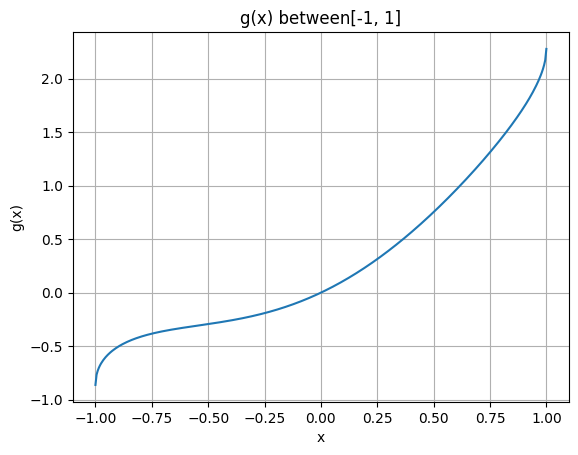

In [19]:
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('g(x)')
plt.title('g(x) between[-1, 1]')
plt.grid(True)
plt.show()

In [20]:
import pandas as pd

In [21]:
s=pd.Series([1,2,3,4,5],index=['a','b','c','d','e'])
s

a    1
b    2
c    3
d    4
e    5
dtype: int64

In [22]:
d=pd.DataFrame([[1,2,3],[4,5,6]],index=['row1','row2'],columns=['col1','col2','col3'])
d

,col1,col2,col3
row1,1,2,3
row2,4,5,6


In [23]:
d2=pd.DataFrame(s)
d2

,0
a,1
b,2
c,3
d,4
e,5


In [24]:
data=pd.read_excel('0901-新生儿体重数据.xlsx')
data

,序号,新生儿体重,怀孕天数,新生儿胎次,孕妇年龄,孕妇身高,孕妇体重,吸烟状况
0,1,120,284,0,27,62,100,0
1,2,113,282,0,33,64,135,0
2,3,128,279,0,28,64,115,1
3,4,123,999,0,36,69,190,0
4,5,108,282,0,23,67,125,1
...,...,...,...,...,...,...,...,...
1231,1232,113,275,1,27,60,100,0
1232,1233,128,265,0,24,67,120,0
1233,1234,130,291,0,30,65,150,1
1234,1235,125,281,1,21,65,110,0


In [49]:
data.describe()

,序号,新生儿体重,怀孕天数,新生儿胎次,孕妇年龄,孕妇身高,孕妇体重,吸烟状况
count,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000
mean,618.500000,119.576861,286.907767,0.254854,27.371359,64.669903,153.976537,0.464401
std,356.946775,18.236452,75.156870,0.435956,6.456992,5.261065,147.872525,0.912102
min,1.000000,55.000000,148.000000,0.000000,15.000000,53.000000,87.000000,0.000000
25%,309.750000,108.750000,272.000000,0.000000,23.000000,62.000000,115.000000,0.000000
50%,618.500000,120.000000,280.000000,0.000000,26.000000,64.000000,126.000000,0.000000
75%,927.250000,131.000000,288.000000,1.000000,31.000000,66.000000,140.000000,1.000000
max,1236.000000,176.000000,999.000000,1.000000,99.000000,99.000000,999.000000,9.000000


In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
# 只对数值型列进行标准化
numeric_cols = data.select_dtypes(include='number').columns
scaler = StandardScaler()
data_standardized = data.copy()
data_standardized[numeric_cols] = scaler.fit_transform(data[numeric_cols])

In [56]:
cols=[x for x in data_standardized.columns if x!='序号']

d:\Anaconda Mini\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


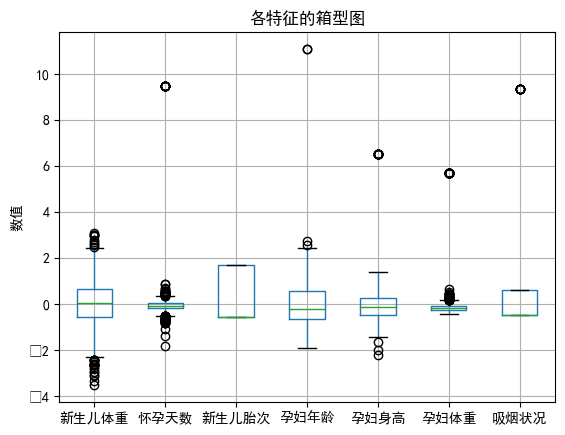

In [57]:
data_standardized[cols].boxplot()
plt.title('各特征的箱型图')
plt.ylabel('数值')
plt.show()

In [44]:
import seaborn as sns

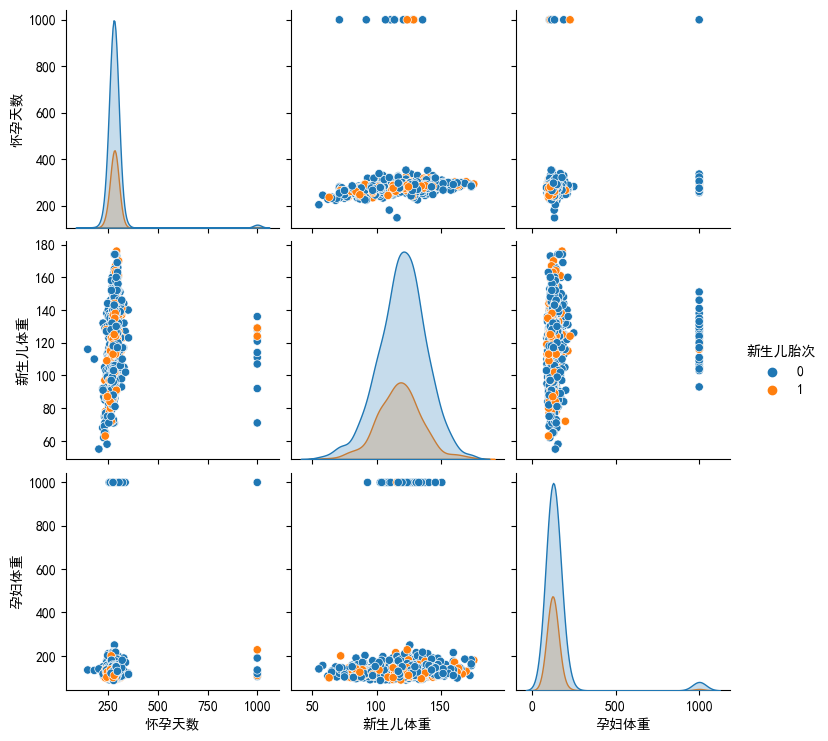

In [47]:
# 假设的DataFrame结构
variables = ['怀孕天数', '新生儿体重', '孕妇体重', '新生儿胎次']
sns.pairplot(data, 
             vars=variables[:3],  # 连续变量
             hue='新生儿胎次',     # 用颜色区分胎次
             diag_kind='kde')

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
model=LinearRegression()
model

LinearRegression()

In [27]:

y=data['新生儿体重']
# x 需要变成二维
X =data[['怀孕天数']] # 或 X = df[['身高']] 也可以
Y = y.values  # y可以直接用一维

In [28]:
from sklearn.model_selection import train_test_split

# X, y 已经准备好，X 必须是二维，y 一维
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
model.fit(X_train,y_train)

LinearRegression()

In [30]:
model.predict(X_test)

array([120.17369938, 119.66102236, 119.8170545 , 120.09939836,
       119.99537694, 119.99537694, 119.98051674, 119.94336623,
       120.01766724, 119.89878562, 120.54520446, 119.89878562,
       120.00280704, 120.11425857, 119.95822643, 120.05481775,
       120.11425857, 120.11425857, 119.97308663, 119.98051674,
       119.66102236, 119.95079633, 120.03995755, 119.94336623,
       119.95079633, 119.70560297, 119.92850602, 119.8096244 ,
       120.00280704, 120.01766724, 120.10682846, 120.19598969,
       119.8244846 , 119.98051674, 119.96565653, 120.07710806,
       119.94336623, 120.30001111, 120.06967796, 119.97308663,
       119.77247389, 120.01766724, 119.90621572, 120.14397897,
       120.11425857, 119.95822643, 119.87649531, 119.98051674,
       120.01023714, 120.08453816, 120.18112948, 120.2628606 ,
       120.05481775, 120.04738765, 119.91364582, 120.09196826,
       120.04738765, 120.06967796, 119.74275348, 120.06224785,
       119.76504379, 119.98794684, 120.01766724, 120.01

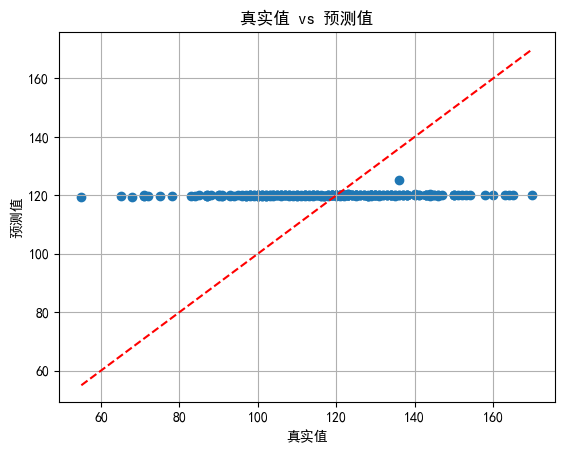

In [31]:
y_pred = model.predict(X_test)
plt.rcParams['font.sans-serif']=['SimHei']
plt.scatter(y_test, y_pred)
plt.xlabel('真实值')
plt.ylabel('预测值')
plt.title('真实值 vs 预测值')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 画一条y=x的参考线
plt.grid(True)
plt.show()

In [32]:
from sklearn import datasets
from sklearn import svm

In [33]:
iris=datasets.load_iris()
print(iris.data.shape)

(150, 4)


In [34]:
clf=svm.LinearSVC()
clf.fit(iris.data,iris.target)
clf.predict([[5.0,3.6,1.3,0.25]])
clf.coef_#每一行为一类的权重

d:\Anaconda Mini\lib\site-packages\sklearn\svm\_base.py:1208: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  ConvergenceWarning,


array([[ 0.18423359,  0.45122726, -0.80794141, -0.45071704],
       [ 0.05512801, -0.89850606,  0.40937945, -0.96181834],
       [-0.85062121, -0.98675382,  1.38105252,  1.86528528]])

In [35]:
from keras.models import Sequential
from keras.layers.core import Dense,Dropout,Activation
from keras.optimizers import SGD

In [36]:
model=Sequential()  # 初始化一个顺序模型，用于按顺序堆叠各层
model.add(Dense(64,input_dim=1))  # 添加输入层（20个节点）到第一隐藏层（64个节点）的全连接层
model.add(Activation('tanh'))  # 第一隐藏层使用tanh激活函数，增加非线性表达能力
model.add(Dropout(0.5))  # 添加Dropout层，防止过拟合，随机丢弃50%的神经元
model.add(Dense(64,input_dim=64))  # 添加第二个全连接层，输入和输出都是64个节点
model.add(Activation('tanh'))  # 第二隐藏层同样使用tanh激活函数
model.add(Dropout(0.5))  # 再次添加Dropout层，进一步防止过拟合
model.add(Dense(1,input_dim=64))  # 添加输出层，输入为64个节点，输出为1个节点（适合二分类）
model.add(Activation('sigmoid'))  # 输出层使用sigmoid激活函数，将输出压缩到0-1之间，适合二分类问题


In [37]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                128       
                                                                 
 activation (Activation)     (None, 64)                0         
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 64)                4160      
                                                                 
 activation_1 (Activation)   (None, 64)                0         
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 6

In [38]:
sgd = SGD(learning_rate=0.1, decay=1e-6, momentum=0.9, nesterov=True)  # 创建一个带有Nesterov动量的SGD优化器，学习率为0.1，权重衰减为1e-6，动量为0.9
model.compile(loss='mean_squared_error', optimizer=sgd)  # 用均方误差作为损失函数，使用上面定义的SGD优化器来编译模型

In [39]:
model.fit(X_train,y_train,epochs=20,batch_size=16)#训练模型
score=model.evaluate(X_test,y_test,batch_size=16)#测试模型
score

Epoch 1/20
62/62 [==============================] - 1s 2ms/step - loss: 14501.2305
Epoch 2/20
62/62 [==============================] - 0s 2ms/step - loss: 14491.5322
Epoch 3/20
62/62 [==============================] - 0s 2ms/step - loss: 14491.5508
Epoch 4/20
62/62 [==============================] - 0s 2ms/step - loss: 14491.4883
Epoch 5/20
62/62 [==============================] - 0s 2ms/step - loss: 14491.0156
Epoch 6/20
62/62 [==============================] - 0s 2ms/step - loss: 14491.2900
Epoch 7/20
62/62 [==============================] - 0s 2ms/step - loss: 14491.0117
Epoch 8/20
62/62 [==============================] - 0s 2ms/step - loss: 14491.0117
Epoch 9/20
62/62 [==============================] - 0s 2ms/step - loss: 14491.3027
Epoch 10/20
62/62 [==============================] - 0s 2ms/step - loss: 14491.0117
Epoch 11/20
62/62 [==============================] - 0s 2ms/step - loss: 14491.3047
Epoch 12/20
62/62 [==============================] - 0s 2ms/step - loss: 14491.0117
E

14001.3916015625

Text(0, 0.5, 'y_train')

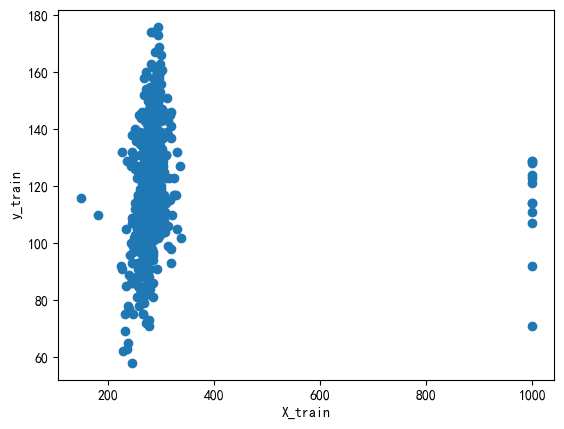

In [40]:
plt.scatter(X_train,y_train)
plt.xlabel('X_train')
plt.ylabel('y_train')